In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('crime_data.csv')

In [3]:
data.head(7)

,timestamp,act379,act13,act279,act323,act363,act302,latitude,longitude
0,28-02-2018 21:00,1,0,0,0,0,0,22.737260,75.875987
1,28-02-2018 21:15,1,0,0,0,0,0,22.720992,75.876083
2,28-02-2018 10:15,0,0,1,0,0,0,22.736676,75.883168
3,28-02-2018 10:15,0,0,1,0,0,0,22.746527,75.887139
4,28-02-2018 10:30,0,0,1,0,0,0,22.769531,75.888772
5,28-02-2018 14:15,0,0,0,1,0,0,22.735218,75.913366
6,28-02-2018 08:00,0,0,0,0,1,0,22.736766,75.908579


In [4]:
data.shape

(2090, 9)

 Act 379-Robbery

 Act 13-Gambling

 Act 279-Accident

 Act 323-Violence

 Act 302-Murder

 Act 363-Kidnapping

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2090 entries, 0 to 2089
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2090 non-null   object 
 1   act379     2090 non-null   int64  
 2   act13      2090 non-null   int64  
 3   act279     2090 non-null   int64  
 4   act323     2090 non-null   int64  
 5   act363     2090 non-null   int64  
 6   act302     2090 non-null   int64  
 7   latitude   2090 non-null   float64
 8   longitude  2090 non-null   float64
dtypes: float64(2), int64(6), object(1)
memory usage: 147.1+ KB


In [6]:
data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')

In [7]:
data['timestamp'] = pd.to_datetime(data['timestamp'], format = '%d/%m/%Y %H:%M:%S')

In [8]:
data['timestamp']

0      2018-02-28 21:00:00
1      2018-02-28 21:15:00
2      2018-02-28 10:15:00
3      2018-02-28 10:15:00
4      2018-02-28 10:30:00
               ...        
2085                   NaT
2086                   NaT
2087                   NaT
2088                   NaT
2089                   NaT
Name: timestamp, Length: 2090, dtype: datetime64[ns]

In [9]:
column_1 = data.iloc[:, 0]
db = pd.DataFrame({
    "year": column_1.dt.year,
    "month": column_1.dt.month,
    "day": column_1.dt.day,
    "hour": column_1.dt.hour,
    "dayofyear": column_1.dt.dayofyear,
    "isoweek": column_1.dt.isocalendar().week,
    "weekofyear": column_1.dt.isocalendar().week,
    "dayofweek": column_1.dt.dayofweek,
    "weekday": column_1.dt.weekday,
    "quarter": column_1.dt.quarter,
})


In [10]:
dataset1=data.drop('timestamp',axis=1)

In [11]:
data1=pd.concat([db,dataset1],axis=1)
data1

,year,month,day,hour,dayofyear,isoweek,weekofyear,dayofweek,weekday,quarter,act379,act13,act279,act323,act363,act302,latitude,longitude
0,2018.0,2.0,28.0,21.0,59.0,9,9,2.0,2.0,1.0,1,0,0,0,0,0,22.737260,75.875987
1,2018.0,2.0,28.0,21.0,59.0,9,9,2.0,2.0,1.0,1,0,0,0,0,0,22.720992,75.876083
2,2018.0,2.0,28.0,10.0,59.0,9,9,2.0,2.0,1.0,0,0,1,0,0,0,22.736676,75.883168
3,2018.0,2.0,28.0,10.0,59.0,9,9,2.0,2.0,1.0,0,0,1,0,0,0,22.746527,75.887139
4,2018.0,2.0,28.0,10.0,59.0,9,9,2.0,2.0,1.0,0,0,1,0,0,0,22.769531,75.888772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2085,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,0,0,0,1,0,0,22.712970,75.823580
2086,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,0,0,0,1,0,0,22.693481,75.821483
2087,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,0,0,1,0,0,0,22.531931,75.769126
2088,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,0,0,1,0,0,0,22.719569,75.857726


In [12]:
data1.shape

(2090, 18)

## Data Analysis

In [13]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2090 entries, 0 to 2089
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        539 non-null    float64
 1   month       539 non-null    float64
 2   day         539 non-null    float64
 3   hour        539 non-null    float64
 4   dayofyear   539 non-null    float64
 5   isoweek     539 non-null    UInt32 
 6   weekofyear  539 non-null    UInt32 
 7   dayofweek   539 non-null    float64
 8   weekday     539 non-null    float64
 9   quarter     539 non-null    float64
 10  act379      2090 non-null   int64  
 11  act13       2090 non-null   int64  
 12  act279      2090 non-null   int64  
 13  act323      2090 non-null   int64  
 14  act363      2090 non-null   int64  
 15  act302      2090 non-null   int64  
 16  latitude    2090 non-null   float64
 17  longitude   2090 non-null   float64
dtypes: UInt32(2), float64(10), int64(6)
memory usage: 281.8 KB


In [14]:
data1.isnull().sum()

year          1551
month         1551
day           1551
hour          1551
dayofyear     1551
isoweek       1551
weekofyear    1551
dayofweek     1551
weekday       1551
quarter       1551
act379           0
act13            0
act279           0
act323           0
act363           0
act302           0
latitude         0
longitude        0
dtype: int64

In [15]:
data1.dropna(inplace=True)

In [16]:
data1.isnull().sum()

year          0
month         0
day           0
hour          0
dayofyear     0
isoweek       0
weekofyear    0
dayofweek     0
weekday       0
quarter       0
act379        0
act13         0
act279        0
act323        0
act363        0
act302        0
latitude      0
longitude     0
dtype: int64

In [17]:
data1.head()

,year,month,day,hour,dayofyear,isoweek,weekofyear,dayofweek,weekday,quarter,act379,act13,act279,act323,act363,act302,latitude,longitude
0,2018.0,2.0,28.0,21.0,59.0,9,9,2.0,2.0,1.0,1,0,0,0,0,0,22.737260,75.875987
1,2018.0,2.0,28.0,21.0,59.0,9,9,2.0,2.0,1.0,1,0,0,0,0,0,22.720992,75.876083
2,2018.0,2.0,28.0,10.0,59.0,9,9,2.0,2.0,1.0,0,0,1,0,0,0,22.736676,75.883168
3,2018.0,2.0,28.0,10.0,59.0,9,9,2.0,2.0,1.0,0,0,1,0,0,0,22.746527,75.887139
4,2018.0,2.0,28.0,10.0,59.0,9,9,2.0,2.0,1.0,0,0,1,0,0,0,22.769531,75.888772


In [18]:
data1.columns[1]

'month'

## Data Visualization & Analysis

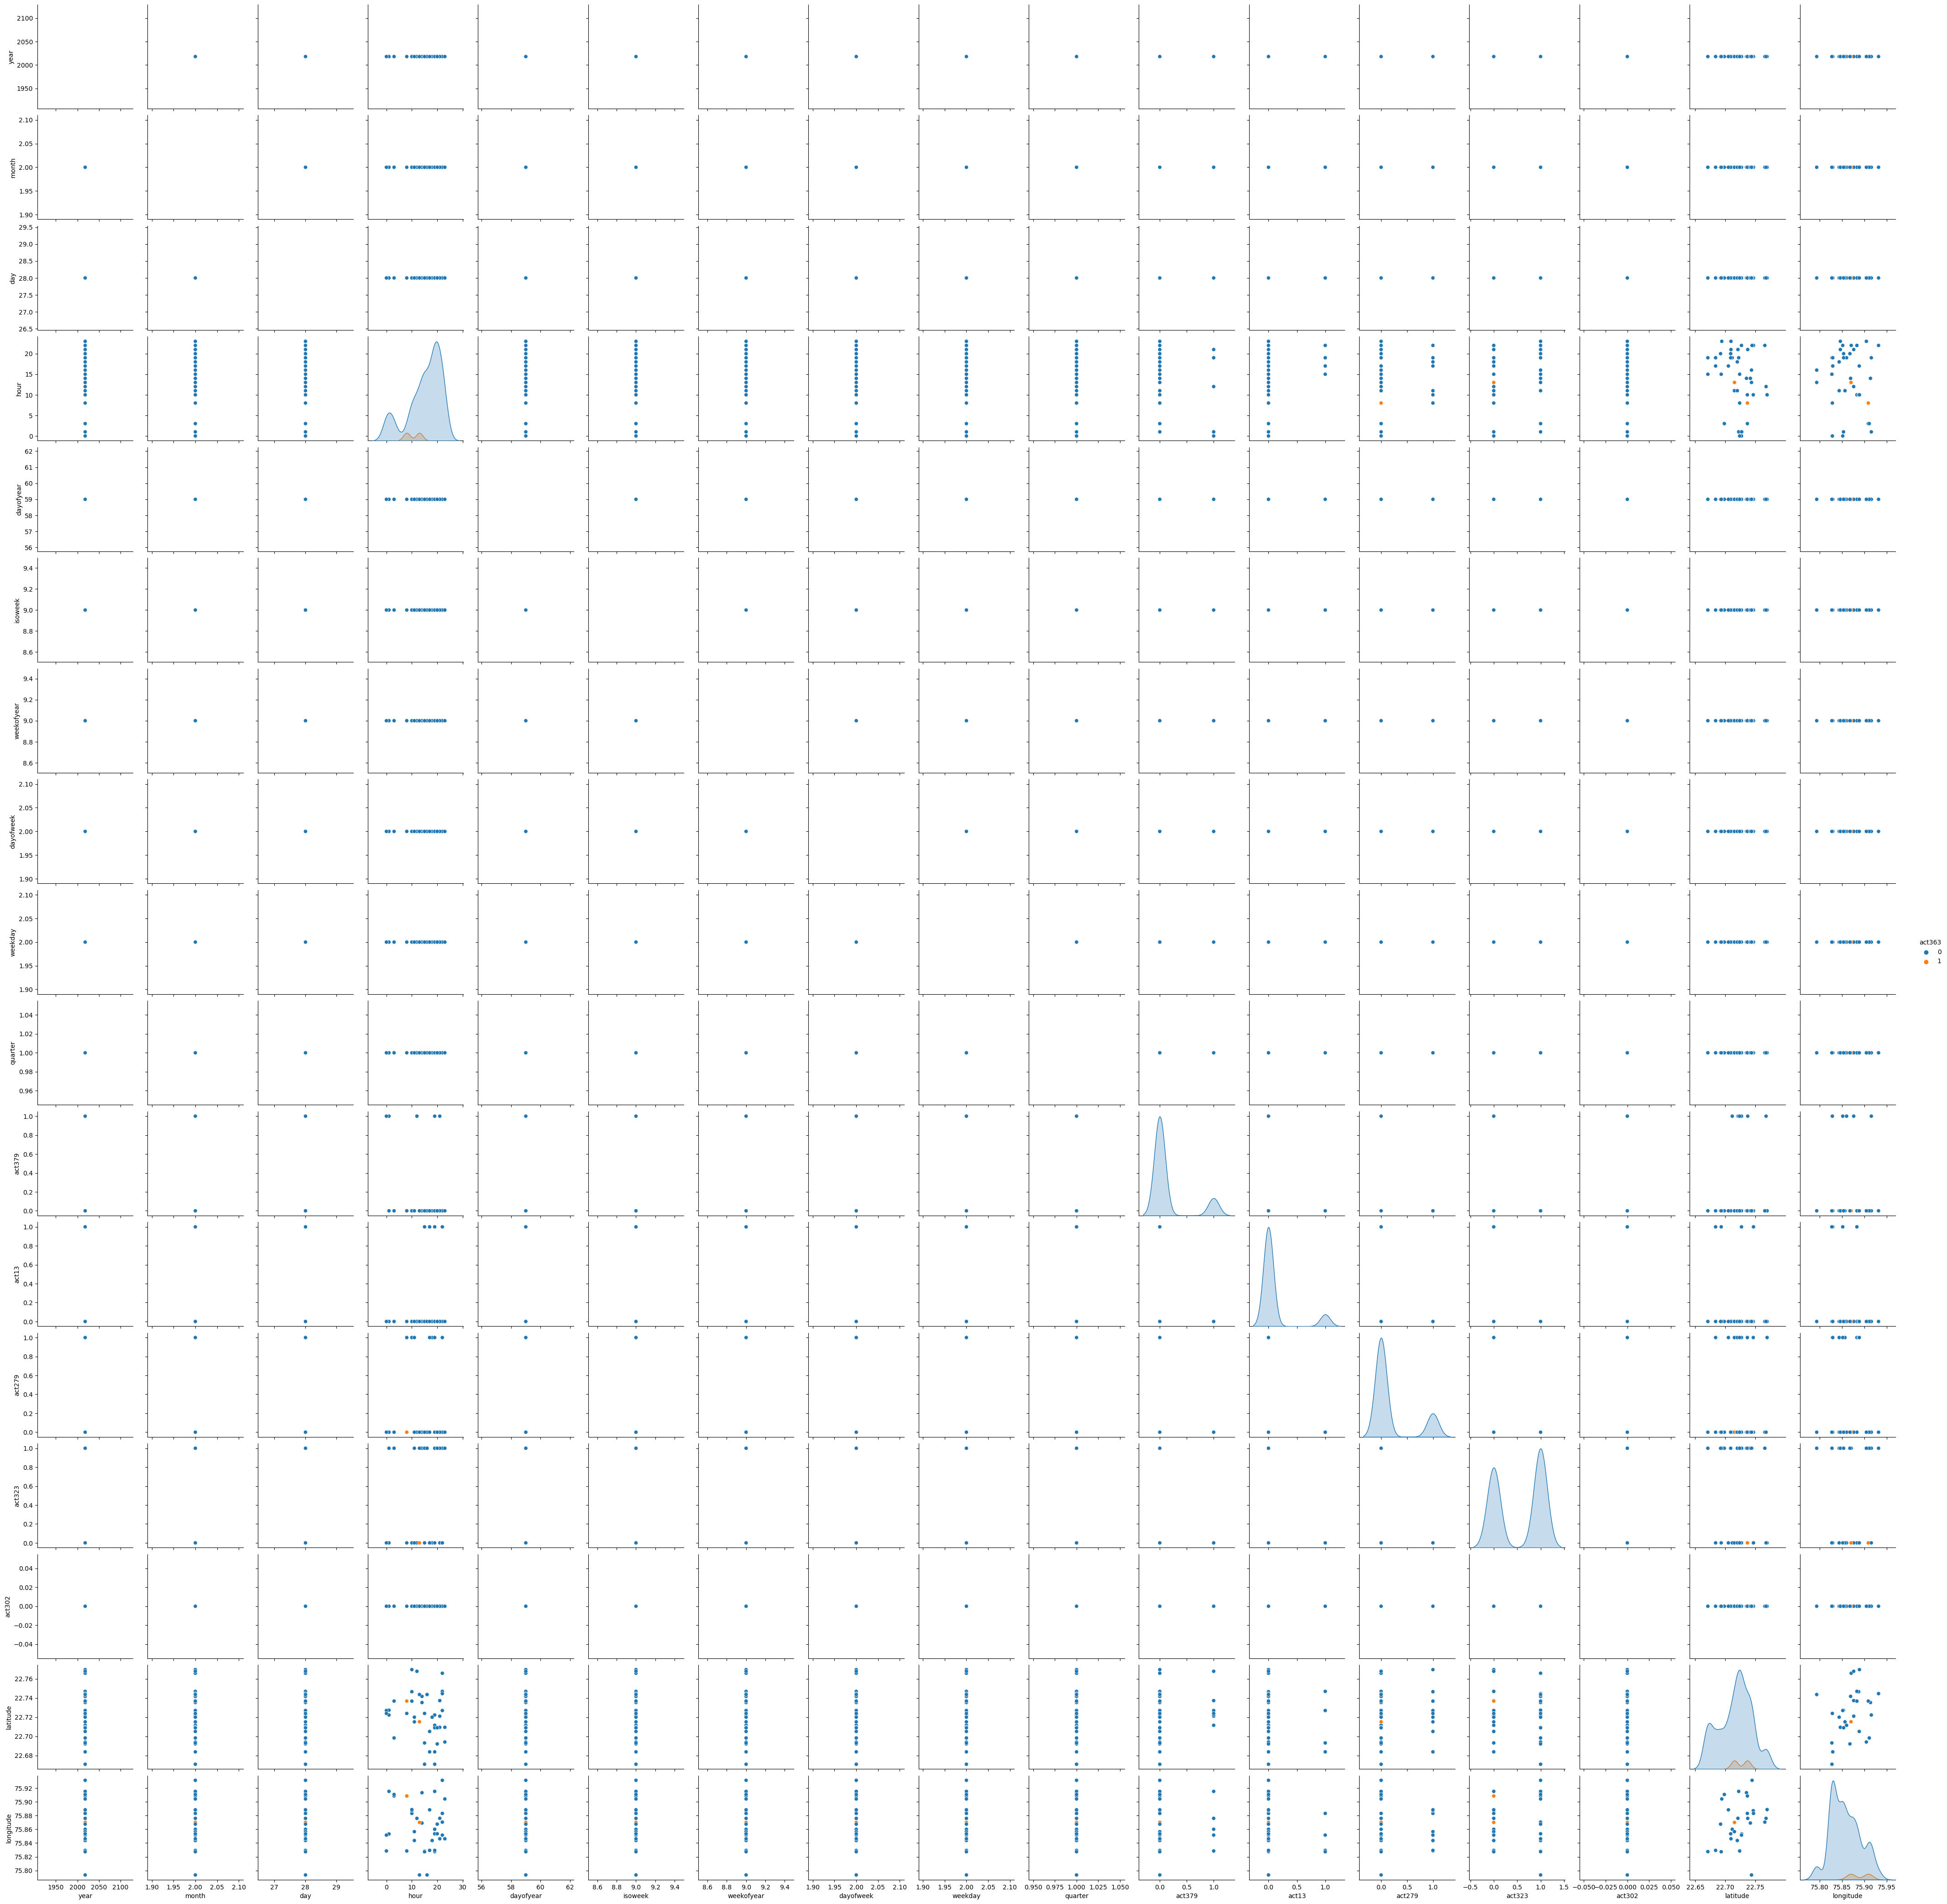

In [19]:
sns.pairplot(data1,hue='act363')

In [20]:
df1 = pd.DataFrame(data=data1, columns=['act13', 'act323', 'act379'])

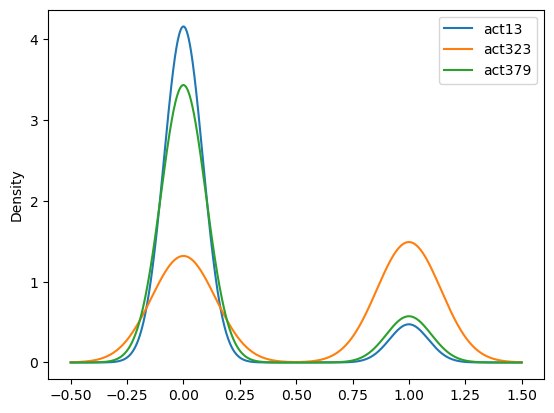

In [21]:
df1.plot.kde()
plt.show()

## X & Y array

In [22]:
data1.head()

,year,month,day,hour,dayofyear,isoweek,weekofyear,dayofweek,weekday,quarter,act379,act13,act279,act323,act363,act302,latitude,longitude
0,2018.0,2.0,28.0,21.0,59.0,9,9,2.0,2.0,1.0,1,0,0,0,0,0,22.737260,75.875987
1,2018.0,2.0,28.0,21.0,59.0,9,9,2.0,2.0,1.0,1,0,0,0,0,0,22.720992,75.876083
2,2018.0,2.0,28.0,10.0,59.0,9,9,2.0,2.0,1.0,0,0,1,0,0,0,22.736676,75.883168
3,2018.0,2.0,28.0,10.0,59.0,9,9,2.0,2.0,1.0,0,0,1,0,0,0,22.746527,75.887139
4,2018.0,2.0,28.0,10.0,59.0,9,9,2.0,2.0,1.0,0,0,1,0,0,0,22.769531,75.888772


In [23]:
data1.shape

(539, 18)

In [24]:
X=data1.iloc[:,[1,2,3,4,6,16,17]].values
#month,day,hour,dayofyear,weekofyear,latitude,longitude

In [25]:
X[4]

array([2.0, 28.0, 10.0, 59.0, 9, 22.769531, 75.888772], dtype=object)

In [26]:
y=data1.iloc[:,[10,11,12,13,14,15]].values
#act379	act13	act279	act323	act363	act302

In [27]:
y[4]

array([0, 0, 1, 0, 0, 0], dtype=int64)

In [28]:
## Splitting the data

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

In [31]:
X_train.shape

(431, 7)

In [32]:
X_test.shape

(108, 7)

## Creating & Training KNN Model

In [33]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=10)

In [34]:
acc1=knn.score(X_test,y_test)
acc1

0.9537037037037037

In [35]:
knn.score(X_train,y_train)

0.9350348027842227

## Creating & Training Decision Tree Model

In [36]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(max_depth=500, random_state=300)

In [37]:
dtree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=500, random_state=300)

In [38]:
y_pred=dtree.predict(X_test)

In [39]:
acc2=dtree.score(X_test,y_test)
acc2

0.9537037037037037

In [40]:
dtree.score(X_train,y_train)

0.9350348027842227

In [41]:
y_pred

array([[0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
 

## Creating & Training Random Forest Model

In [42]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X_train, y_train)

RandomForestClassifier()

In [43]:
y_pred=rfc.predict(X_test)

In [44]:
X_test[0]

array([2.0, 28.0, 22.0, 59.0, 9, 22.765772, 75.870461], dtype=object)

In [45]:
X_test[10]

array([2.0, 28.0, 8.0, 59.0, 9, 22.723873, 75.828416], dtype=object)

In [46]:
y_pred[10]

array([0, 0, 1, 0, 0, 0], dtype=int64)

In [47]:
acc3=rfc.score(X_test,y_test)
acc3

0.9629629629629629

In [48]:
rfc.score(X_train,y_train)

0.9582366589327146

# Prediction

In [49]:
test_vector = np.reshape(np.asarray([2., 28., 15., 59. ,  9. , 22.723873,75.828416]),(1,7))
p =np.array(rfc.predict(test_vector)[0])

print(p)

label = ['Robbery','Gambling','Accident','Violence','Kidnapping','Murder']
print (label[3])

[0 0 0 1 0 0]
Violence


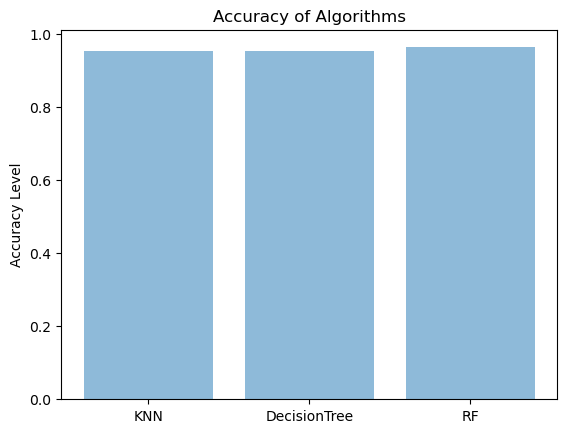

In [50]:
import matplotlib.pyplot as plt; plt.rcdefaults()
import numpy as np
import matplotlib.pyplot as plt
 
objects = ('KNN','DecisionTree','RF')
y_pos = np.arange(len(objects))
performance = [acc1,acc2,acc3]
 
plt.bar(y_pos, performance, align='center', alpha=0.5)
plt.xticks(y_pos, objects)
plt.ylabel('Accuracy Level')
plt.title('Accuracy of Algorithms')
 
plt.show()

In [51]:
test_vector = np.reshape(np.asarray([  2.      , 28.      , 21.      , 59.      ,  9.      , 22.73726 ,
       75.875987]),(1,7))
p =np.array(rfc.predict(test_vector)[0])

print(p)

label = ['Robbery','Gambling','Accident','Violence','Kidnapping','Murder']
if p[0] == 1:
    print("Robbery")
if p[0] ==2:
    print("Gambling")
if p[0] ==3:
    print("Accident")
if p[0] ==4:
    print("Violence")
if p[0] ==5:
    print("Kidnapping")
if p[0] ==6:
    print("Murder")

[1 0 0 0 0 0]
Robbery


In [52]:
test_vector = np.reshape(np.asarray([2.      , 28.      , 10.      , 59.      ,  9.      , 22.769531,
       75.888772]),(1,7))
p =np.array(rfc.predict(test_vector)[0])

print(p)

label = ['Robbery','Gambling','Accident','Violence','Kidnapping','Murder']
if p[0] == 1:
    print("Robbery")
if p[1] ==1:
    print("Gambling")
if p[2] ==1:
    print("Accident")
if p[3] ==1:
    print("Violence")
if p[4] ==1:
    print("Kidnapping")
if p[5] ==1:
    print("Murder")

[0 0 1 0 0 0]
Accident


In [53]:
import pickle
pickle.dump(rfc, open('model.pkl','wb'))
model = pickle.load(open('model.pkl','rb'))